In [ ]:
!pip install natsort

In [3]:
import shutil
from glob import glob
import os
import re
from moviepy.editor import VideoFileClip, concatenate_videoclips
from natsort import natsorted
from pathlib import Path

# паттерн для идентификатора мышесессии
#pattern = r'[A-z0-9]{3,4}_[A-z]{1,2}\d{2}_(\dD|\dT)(_\dT)?'
pattern = re.compile(r"[A-Za-z0-9]{3,6}_[A-Za-z]{1,2}\d{2}_(\d{1,2}[DT])(_\d{1,2}T)?")

# укажи путь к папке с папками мышейсессий, добавь двойные слеши
root = Path(r"h:\BOWL\BehaviorSide2Data\1_Raw2")

# укажи путь выходных данных
output_folder = Path(r"h:\BOWL\BehaviorSide2Data\2_Combined")

# выбери структуру папок
# For Bonsai data
timestamps = list(root.rglob("*.csv"))
# or For MiniscopeSoft data
#timestamps = list(root.rglob("*//*//*//Miniscope//timeStamps.csv"))

print(f"Найдено всего {len(timestamps)} таймстемпов")
timestamps

Найдено всего 15 таймстемпов


[WindowsPath('h:/BOWL/BehaviorSide2Data/1_Raw2/BOF_D01_5D/BOF_D01_5D_VT_TS.csv'),
 WindowsPath('h:/BOWL/BehaviorSide2Data/1_Raw2/BOF_D03_5D/BOF_D03_5D_VT_TS.csv'),
 WindowsPath('h:/BOWL/BehaviorSide2Data/1_Raw2/BOF_D04_5D/BOF_D04_5D_VT_TS.csv'),
 WindowsPath('h:/BOWL/BehaviorSide2Data/1_Raw2/BOF_D07_5D/BOF_D07_5D_VT_TS.csv'),
 WindowsPath('h:/BOWL/BehaviorSide2Data/1_Raw2/BOF_D14_5D/BOF_D14_5D_VT_TS.csv'),
 WindowsPath('h:/BOWL/BehaviorSide2Data/1_Raw2/BOF_D17_5D/BOF_D17_5D_VT_TS.csv'),
 WindowsPath('h:/BOWL/BehaviorSide2Data/1_Raw2/BOF_F05_5D/BOF_F05_5D_.csv'),
 WindowsPath('h:/BOWL/BehaviorSide2Data/1_Raw2/BOF_F09_5D/BOF_F09_5D_.csv'),
 WindowsPath('h:/BOWL/BehaviorSide2Data/1_Raw2/BOF_F11_5D/BOF_F11_5D_.csv'),
 WindowsPath('h:/BOWL/BehaviorSide2Data/1_Raw2/BOF_F15_5D/BOF_F15_5D_.csv'),
 WindowsPath('h:/BOWL/BehaviorSide2Data/1_Raw2/BOF_F35_5D/BOF_F52_5D_.csv'),
 WindowsPath('h:/BOWL/BehaviorSide2Data/1_Raw2/BOF_F37_5D/BOF_F37_5D_.csv'),
 WindowsPath('h:/BOWL/BehaviorSide2Data/1_Raw2

In [4]:
for tm in timestamps:
    splitted_path = os.path.normpath(tm).split(os.sep)

    # Поиск индекса каталога, совпадающего с шаблоном
    identifier_index = None
    for i, directory in enumerate(splitted_path):
        if re.match(pattern, directory):
            print(directory)
            identifier_index = i
            break
    
    # Вывод результата
    if identifier_index is not None:
        print(f"Идентификатор найден: '{splitted_path[identifier_index]}'")
    else:
        print("Идентификатор не найден в пути.")    
    
    mouse_name = splitted_path[identifier_index]
            
    # Считывает файлы и сортирует          
    avi_files = glob(os.path.dirname(tm) + '\\*.avi')    
    avi_files = natsorted(avi_files)
    print("\n".join(avi_files))
    
    # Объединяет видео и сохраняет
    clips = []
    for av in avi_files:            
        clips.append(VideoFileClip(av))
    result = concatenate_videoclips(clips, method='compose')    
    
    # поменять для поведения 
    output_path = output_folder / f"{mouse_name}.mp4"
    result.write_videofile(str(output_path))


BOF_D01_5D
Идентификатор найден: 'BOF_D01_5D'
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_0.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_1.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_2.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_3.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_4.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_5.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_6.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_7.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_8.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_9.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_10.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_11.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_12.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_13.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D01_5D\BOF_D01_5D_14.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\B

Moviepy - Done !
Moviepy - video ready h:\BOWL\BehaviorSide2Data\2_Combined\BOF_D01_5D.mp4
BOF_D03_5D
Идентификатор найден: 'BOF_D03_5D'
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D03_5D\BOF_D03_5D_0.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D03_5D\BOF_D03_5D_1.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D03_5D\BOF_D03_5D_2.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D03_5D\BOF_D03_5D_3.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D03_5D\BOF_D03_5D_4.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D03_5D\BOF_D03_5D_5.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D03_5D\BOF_D03_5D_6.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D03_5D\BOF_D03_5D_7.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D03_5D\BOF_D03_5D_8.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D03_5D\BOF_D03_5D_9.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D03_5D\BOF_D03_5D_10.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D03_5D\BOF_D03_5D_11.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D03_5D\BOF_D03_5D_12.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D03_5D\BOF_D03_5D_13.avi
h:\BO

Moviepy - Done !
Moviepy - video ready h:\BOWL\BehaviorSide2Data\2_Combined\BOF_D03_5D.mp4
BOF_D04_5D
Идентификатор найден: 'BOF_D04_5D'
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D04_5D\BOF_D04_5D_0.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D04_5D\BOF_D04_5D_1.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D04_5D\BOF_D04_5D_2.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D04_5D\BOF_D04_5D_3.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D04_5D\BOF_D04_5D_4.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D04_5D\BOF_D04_5D_5.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D04_5D\BOF_D04_5D_6.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D04_5D\BOF_D04_5D_7.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D04_5D\BOF_D04_5D_8.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D04_5D\BOF_D04_5D_9.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D04_5D\BOF_D04_5D_10.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D04_5D\BOF_D04_5D_11.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D04_5D\BOF_D04_5D_12.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D04_5D\BOF_D04_5D_13.avi
h:\BO

Moviepy - Done !
Moviepy - video ready h:\BOWL\BehaviorSide2Data\2_Combined\BOF_D04_5D.mp4
BOF_D07_5D
Идентификатор найден: 'BOF_D07_5D'
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D07_5D\BOF_D07_5D_0.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D07_5D\BOF_D07_5D_1.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D07_5D\BOF_D07_5D_2.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D07_5D\BOF_D07_5D_3.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D07_5D\BOF_D07_5D_4.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D07_5D\BOF_D07_5D_5.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D07_5D\BOF_D07_5D_6.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D07_5D\BOF_D07_5D_7.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D07_5D\BOF_D07_5D_8.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D07_5D\BOF_D07_5D_9.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D07_5D\BOF_D07_5D_10.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D07_5D\BOF_D07_5D_11.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D07_5D\BOF_D07_5D_12.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D07_5D\BOF_D07_5D_13.avi
h:\BO

Moviepy - Done !
Moviepy - video ready h:\BOWL\BehaviorSide2Data\2_Combined\BOF_D07_5D.mp4
BOF_D14_5D
Идентификатор найден: 'BOF_D14_5D'
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D14_5D\BOF_D14_5D_0.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D14_5D\BOF_D14_5D_1.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D14_5D\BOF_D14_5D_2.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D14_5D\BOF_D14_5D_3.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D14_5D\BOF_D14_5D_4.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D14_5D\BOF_D14_5D_5.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D14_5D\BOF_D14_5D_6.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D14_5D\BOF_D14_5D_7.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D14_5D\BOF_D14_5D_8.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D14_5D\BOF_D14_5D_9.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D14_5D\BOF_D14_5D_10.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D14_5D\BOF_D14_5D_11.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D14_5D\BOF_D14_5D_12.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_D14_5D\BOF_D14_5D_13.avi
h:\BO

...

Moviepy - Done !
Moviepy - video ready h:\BOWL\BehaviorSide2Data\2_Combined\BOF_F35_5D.mp4
BOF_F37_5D
Идентификатор найден: 'BOF_F37_5D'
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F37_5D\BOF_F37_5D_0.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F37_5D\BOF_F37_5D_1.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F37_5D\BOF_F37_5D_2.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F37_5D\BOF_F37_5D_3.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F37_5D\BOF_F37_5D_4.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F37_5D\BOF_F37_5D_5.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F37_5D\BOF_F37_5D_6.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F37_5D\BOF_F37_5D_7.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F37_5D\BOF_F37_5D_8.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F37_5D\BOF_F37_5D_9.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F37_5D\BOF_F37_5D_10.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F37_5D\BOF_F37_5D_11.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F37_5D\BOF_F37_5D_12.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F37_5D\BOF_F37_5D_13.avi
h:\BO

Moviepy - Done !
Moviepy - video ready h:\BOWL\BehaviorSide2Data\2_Combined\BOF_F37_5D.mp4
BOF_F43_5D
Идентификатор найден: 'BOF_F43_5D'
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F43_5D\BOF_F43_5D_0.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F43_5D\BOF_F43_5D_1.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F43_5D\BOF_F43_5D_2.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F43_5D\BOF_F43_5D_3.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F43_5D\BOF_F43_5D_4.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F43_5D\BOF_F43_5D_5.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F43_5D\BOF_F43_5D_6.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F43_5D\BOF_F43_5D_7.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F43_5D\BOF_F43_5D_8.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F43_5D\BOF_F43_5D_9.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F43_5D\BOF_F43_5D_10.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F43_5D\BOF_F43_5D_11.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F43_5D\BOF_F43_5D_12.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F43_5D\BOF_F43_5D_13.avi
h:\BO

Moviepy - Done !
Moviepy - video ready h:\BOWL\BehaviorSide2Data\2_Combined\BOF_F43_5D.mp4
BOF_F48_5D
Идентификатор найден: 'BOF_F48_5D'
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F48_5D\BOF_F48_5D_0.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F48_5D\BOF_F48_5D_1.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F48_5D\BOF_F48_5D_2.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F48_5D\BOF_F48_5D_3.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F48_5D\BOF_F48_5D_4.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F48_5D\BOF_F48_5D_5.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F48_5D\BOF_F48_5D_6.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F48_5D\BOF_F48_5D_7.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F48_5D\BOF_F48_5D_8.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F48_5D\BOF_F48_5D_9.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F48_5D\BOF_F48_5D_10.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F48_5D\BOF_F48_5D_11.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F48_5D\BOF_F48_5D_12.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F48_5D\BOF_F48_5D_13.avi
h:\BO

Moviepy - Done !
Moviepy - video ready h:\BOWL\BehaviorSide2Data\2_Combined\BOF_F48_5D.mp4
BOF_F54_5D
Идентификатор найден: 'BOF_F54_5D'
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F54_5D\BOF_F54_5D_0.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F54_5D\BOF_F54_5D_1.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F54_5D\BOF_F54_5D_2.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F54_5D\BOF_F54_5D_3.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F54_5D\BOF_F54_5D_4.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F54_5D\BOF_F54_5D_5.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F54_5D\BOF_F54_5D_6.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F54_5D\BOF_F54_5D_7.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F54_5D\BOF_F54_5D_8.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F54_5D\BOF_F54_5D_9.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F54_5D\BOF_F54_5D_10.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F54_5D\BOF_F54_5D_11.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F54_5D\BOF_F54_5D_12.avi
h:\BOWL\BehaviorSide2Data\1_Raw2\BOF_F54_5D\BOF_F54_5D_13.avi
h:\BO

Moviepy - Done !
Moviepy - video ready h:\BOWL\BehaviorSide2Data\2_Combined\BOF_F54_5D.mp4


In [10]:
print(identifier_index)

None


In [ ]:
## import shutil
# ToDo naming for 1 mode is wrong (only mouse id)

from glob import glob
import os
import re
from moviepy.editor import VideoFileClip, concatenate_videoclips
from natsort import natsorted

# Паттерн для идентификатора мышесессии вида "MSS_F01_1D_1T"
pattern = r'[A-Z]{3,4}_[A-Z]\d{2}_(\dD|\dT)(_\dT)?'

# Укажите путь к корневой папке с папками мышесессий
exp = 'HOS'
root = 'w:\\Projects\\HOS\\BehaviorData\\1_Raw\\'

# Выберите режим работы:
# 1 - Сшить все видео из одной папки
#mode = '1'
# 2 - Сшить все видео, относящиеся к одной мыши
mode = '1'

timestamps = glob(root + '*//*.csv')
print(f"Найдено всего {len(timestamps)} таймстемпов")
timestamps

if mode not in ["1", "2"]:
    print("Неверный выбор режима. Завершение программы.")
    exit()

# Множество для отслеживания обработанных идентификаторов мышей (только для режима 2)
processed_mice = set()

for tm in timestamps:
    splitted_path = os.path.normpath(tm).split(os.sep)

    # Поиск идентификатора мышесессии
    identifier_index = None
    for i, directory in enumerate(splitted_path):
        if re.match(pattern, directory):
            identifier_index = i
            break
    
    if identifier_index is None:
        print(f"Идентификатор не найден в пути: {tm}")
        continue
    
    mouse_session = splitted_path[identifier_index]
    
    # Извлекаем идентификатор мыши (например, F04 из MSS_F04_1D_1T)
    mouse_id_match = re.search(r'_([A-Z]\d{2})_', mouse_session)
    if not mouse_id_match:
        print(f"Не удалось извлечь идентификатор мыши из: {mouse_session}")
        continue
    mouse_id = mouse_id_match.group(1)

    # Проверка для режима 2: пропускаем уже обработанных мышей
    if mode == "2" and mouse_id in processed_mice:
        continue

    # Получение списка видео в зависимости от режима
    avi_files = []
    if mode == "1":  # Режим 1: Сшить видео из одной папки
        avi_files = glob(os.path.dirname(tm) + '\\*.avi')
    elif mode == "2":  # Режим 2: Сшить все видео по идентификатору мыши
        avi_files = glob(root + '**/*.avi', recursive=True)
        avi_files = [file for file in avi_files if f"_{mouse_id}_" in os.path.basename(file)]
        processed_mice.add(mouse_id)  # Отмечаем идентификатор как обработанный
    
    if not avi_files:
        print(f"Видео не найдены для {mouse_id}. Пропуск.")
        continue

    # Сортировка файлов в алфавитном порядке
    avi_files = natsorted(avi_files)
    print(f"Найдено {len(avi_files)} видео для {mouse_id}:")
    print("\n".join(avi_files))

    # Объединение видео и сохранение
    clips = []
    for av in avi_files:
        clips.append(VideoFileClip(av))
    result = concatenate_videoclips(clips, method='compose')

    # Сохранение результата
    output_file = os.path.join(root, f"{exp}_{mouse_id}.mp4")
    result.write_videofile(output_file)
    print(f"Видео сохранено: {output_file}")


In [ ]:
from moviepy.editor import *
import subprocess
import os
import re
from glob import glob
from natsort import natsorted

def compress_video_crf(input_path, output_path, crf=23):
    """Сжатие видео с постоянным качеством (CRF)"""
    cmd = [
        'ffmpeg',
        '-i', input_path,
        '-c:v', 'libx264',
        '-crf', str(crf),
        '-preset', 'medium',
        '-c:a', 'aac',
        '-b:a', '128k',
        '-y',
        output_path
    ]
    subprocess.run(cmd, check=True)

def get_video_bitrate(filename):
    """Получение битрейта видео"""
    cmd = [
        'ffprobe', 
        '-v', 'error',
        '-select_streams', 'v:0',
        '-show_entries', 'stream=bit_rate',
        '-of', 'default=noprint_wrappers=1:nokey=1',
        filename
    ]
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        bitrate = int(result.stdout.strip())
        return bitrate / 1000  # конвертируем в кбит/с
    except:
        return None

# Ваш основной код
for tm in timestamps:
    splitted_path = os.path.normpath(tm).split(os.sep)

    # Поиск индекса каталога, совпадающего с шаблоном
    identifier_index = None
    for i, directory in enumerate(splitted_path):
        if re.match(pattern, directory):
            print(directory)
            identifier_index = i
            break
    
    # Вывод результата
    if identifier_index is not None:
        print(f"Идентификатор найден: '{splitted_path[identifier_index]}'")
    else:
        print("Идентификатор не найден в пути.")    
    
    mouse_name = splitted_path[identifier_index]
            
    # Считывает файлы и сортирует          
    avi_files = glob(os.path.dirname(tm) + '\\*.avi')    
    avi_files = natsorted(avi_files)
    print("\n".join(avi_files))
    
    # Объединяет видео и сохраняет
    clips = []
    temp_compressed_files = []  # для хранения временных сжатых файлов
    
    for av in avi_files:
        # Проверяем битрейт исходного файла
        bitrate = get_video_bitrate(av)
        
        if bitrate and bitrate > 10000:
            print(f"Битрейт слишком высокий: {bitrate} кбит/с. Сжимаю {os.path.basename(av)}...")
            
            # Создаем временный файл для сжатого видео
            temp_compressed = f"temp_compressed_{os.path.basename(av)}.mp4"
            compress_video_crf(av, temp_compressed, crf=25)
            
            # Добавляем сжатый клип
            clips.append(VideoFileClip(temp_compressed))
            temp_compressed_files.append(temp_compressed)
        else:
            print(f"Битрейт приемлемый: {bitrate} кбит/с. Использую оригинал {os.path.basename(av)}")
            clips.append(VideoFileClip(av))
    
    # Склеиваем все клипы
    result = concatenate_videoclips(clips, method='compose')    
    
    # Сохраняем финальное видео
    output_path = os.path.join(output_folder, mouse_name + '.mp4')    
    result.write_videofile(output_path)

    # Закрываем клипы для освобождения ресурсов
    result.close()
    for clip in clips:
        clip.close()
    
    # Ждем немного чтобы освободились файловые дескрипторы
    import time
    time.sleep(1)

    # Очищаем временные файлы
    for temp_file in temp_compressed_files:
        if os.path.exists(temp_file):
            os.remove(temp_file)

print("Обработка завершена!")

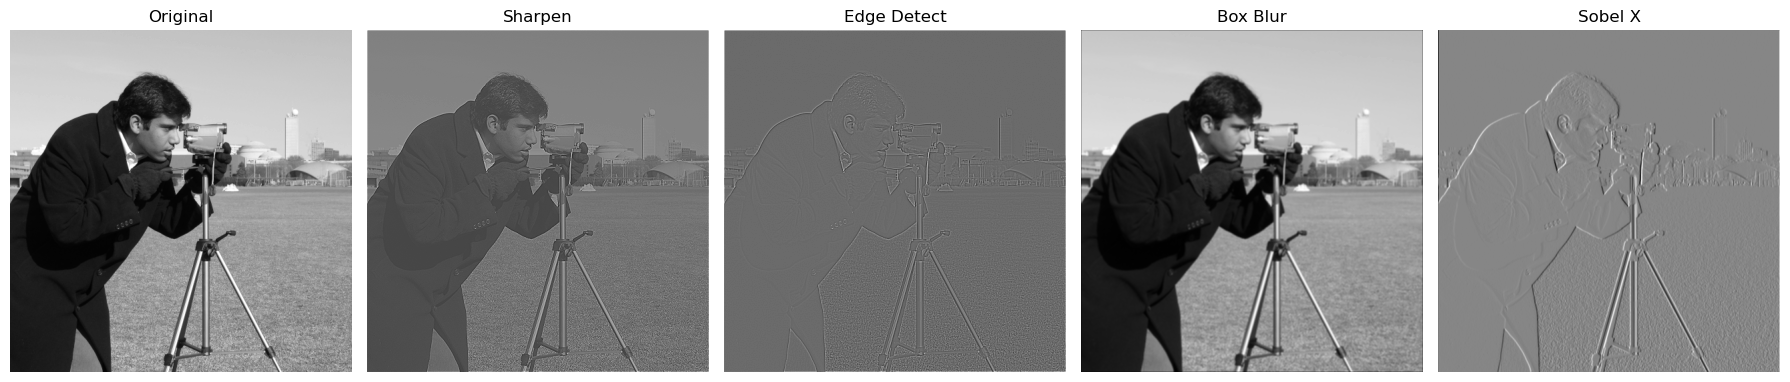

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import convolve2d
from skimage import data

# Load sample image
img = data.camera()

# Define several convolution kernels
kernels = {
    "Sharpen": np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]),
    "Edge Detect": np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]]),
    "Box Blur": np.ones((3,3))/9,
    "Sobel X": np.array([[-1,0,1],[-2,0,2],[-1,0,1]]),
}

# Apply convolutions
results = {name: convolve2d(img, k, mode='same', boundary='fill', fillvalue=0) 
           for name,k in kernels.items()}

# Plot
fig, axes = plt.subplots(1, 5, figsize=(18,4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

for ax, (name, out) in zip(axes[1:], results.items()):
    ax.imshow(out, cmap='gray')
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.show()
